In [ ]:
%load_ext autoreload
%autoreload 2
import os
print(os.getcwd())

/home/as/code/ai/susteelaible/nlp


# bert-1
- run pipeline

In [ ]:
from nlp import ClimateBERTAnalyzer, analyze_reports

stats = analyze_reports('../data/reports/Baosteel')
# stats = analyze_reports("../data/reports")

# bert-2
- run vizualisations

In [ ]:
from nlp import ClimateBERTVisualizer, visualize_results

visualize_results("../cache", "../out")

✅ Loaded: 15 reports, 1 companies, 2013-2020

EXPORTING CSV FILES
   ✓ company_year.csv (8 rows)
   ✓ company_totals.csv (1 companies)
   ✓ yearly_industry.csv (8 years)
   ✓ funnel_company_year.csv (8 rows)

   📁 All CSVs saved to: ../out/

GENERATING PLOTS
   ✓ slide_main.png
   ✓ slide_sentiment_trend.png
   ✓ talk_score_trend.png
   ✓ funnel_trend.png
   ✓ talk_score_per_company.png
   ✓ per_company_components.png
   ✓ per_company_sentiment.png
   ✓ sentiment_all_companies.png
   ✓ n0_funnel.png
   ✓ n0_quality_comparison.png
   ✓ n0_per_company.png
   ✓ n0_gap_analysis.png

   📁 All plots saved to: ../out/

   Generating word frequency plots...

   📊 ALL CHUNKS (top 30):
   environment(1232), iron(766), management(736), development(720), energy(628), technology(609), products(607), protection(559), production(525), industry(522), green(473), emission(453), system(428), reduction(421), base(410)

   🌱 OPPORTUNITY chunks (top 15):
   environment(809), development(574), technology(52

# rag 1

In [ ]:
from nlp import quick_start, RAGConfig, analyze_token_usage

# Configure RAG pipeline parameters here
rag_config = RAGConfig(
    cache_dir="../cache",
    use_bert_cache=True,
    output_folder="../out",

    # LLM settings
    ollama_model="qwen3:4b",  # or "gemma3:4b", "phi3:mini"
    ollama_base_url="http://localhost:11434",
    llm_temperature=0.0,
    llm_num_ctx=4096,  # Context window size

    # Extraction settings
    max_chunks_per_group=15,  # Limit chunks sent to LLM per company-year
    # if ++ will spill CPU or notify or silent truncate?

    # BERT filtering (reduce chunk count by filtering low-confidence chunks)
    min_detector_score=0.7,  # 0.0 = no filter, 0.7 = keep only confident climate chunks
)

# Initialize pipeline and analyze token usage
pipeline = quick_start(config=rag_config)
stats = analyze_token_usage(pipeline)
# pipeline.print_status()

# Auto-apply recommended max_chunks_per_group (optional)
# rag_config.max_chunks_per_group = stats["recommendations"]["max_chunks_for_ctx"]

✓ RAG Pipeline initialized (GPU: NVIDIA T1200 Laptop GPU (3.9GB))
✓ Filtered 1048 chunks below detector_score=0.7 (14545 remaining)
('001', '2022'): 503 chunks
('001', '2023'): 487 chunks
('001', '2021'): 484 chunks
('015', '2024'): 344 chunks
('001', '2019'): 338 chunks
('001', '2024'): 336 chunks
('001', '2020'): 332 chunks
('003', '2024'): 279 chunks
('015', '2025'): 277 chunks
('001', '2013'): 262 chunks
✓ Loaded 14545 chunks from 15 companies (../cache)
PROMPT OVERHEAD
  BARRIER_MAP_PROMPT:   ~610 tokens (2443 chars)
  MOTIVATOR_MAP_PROMPT: ~592 tokens (2370 chars)
  Using max as overhead: 610 tokens

CHUNK-LEVEL STATISTICS
Total chunks: 14545

Chunk size (characters):
  Min: 38, Max: 19629, Mean: 1753, Median: 1453

Chunk size (tokens, approx):
  Min: 9, Max: 4907, Mean: 438, Median: 363

GROUP-LEVEL STATISTICS (company-year)
Total groups: 132

Chunks per group:
  Min: 5, Max: 503, Mean: 110.2, Median: 86

Tokens per group (incl. prompt overhead):
  Min: 1678, Max: 232190, Mean: 

In [15]:
%timeit
# pipeline.inspect_pipeline_status()
pipeline.extract_all_companies()


EXTRACTING ALL COMPANIES
Total groups: 132
LLM context: 4096 tokens

Extracting: ArcelorMittal (001)
Years: ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Groups: 13 | Avg chunks/group: 110.2


  001:   0%|          | 0/13 [00:00<?, ?it/s]

Loading Ollama model: qwen3:4b


KeyboardInterrupt: 

# rag 2

/home/as/code/ai/susteelaible/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📝 Config logged to ../out/topics5/config_log.txt

📂 LOADING DATA

📂 Loading 7 CSV files from ../out...


Reading CSV files: 100%|██████████| 7/7 [00:00<00:00, 329.44it/s]


✅ Loaded 979 rows from 7 files

📂 Loading 7 CSV files from ../out...


Reading CSV files: 100%|██████████| 7/7 [00:00<00:00, 193.81it/s]

...


✅ Found 9 topics
   📍 421 documents classified as outliers (topic -1)
✅ Saved model to ../out/topics5/motivators_model
✅ Saved embeddings to ../out/topics5/motivators_embeddings.npy

📋 Topic Summary:
------------------------------------------------------------
Topic -1:  421 docs | carbon emissions, co2 emissions, sustainability, emissions, energy efficiency
Topic 0:  254 docs | steel production, energy efficiency, low carbon, steelmaking, steel products
Topic 1:  144 docs | reduce emissions, reduce co2, minimize emissions, co2 emissions, carbon emissions
Topic 2:  136 docs | human rights, health safety, compliance, safety work, safety
Topic 3:   48 docs | capital expenditure, capital employed, expenditure, cost capital, ebitda
Topic 4:   32 docs | motivating factors, motivators qualifying, qualifying motivators, motivators extracted, motivating
Topic 5:   31 docs | olkiluoto nuclear, nuclear power, power procurement, power plant, power production
Topic 6:   26 docs | emission rights,

13it [00:15,  1.18s/it]


  ✓ motivators_over_time.html


7it [00:08,  1.22s/it]


  ✓ motivators_per_company.html
  ✓ motivators_datamap.png
  ✓ Saved motivators_company_year.csv

✅ PIPELINE COMPLETE
📁 Results saved to: ../out/topics5


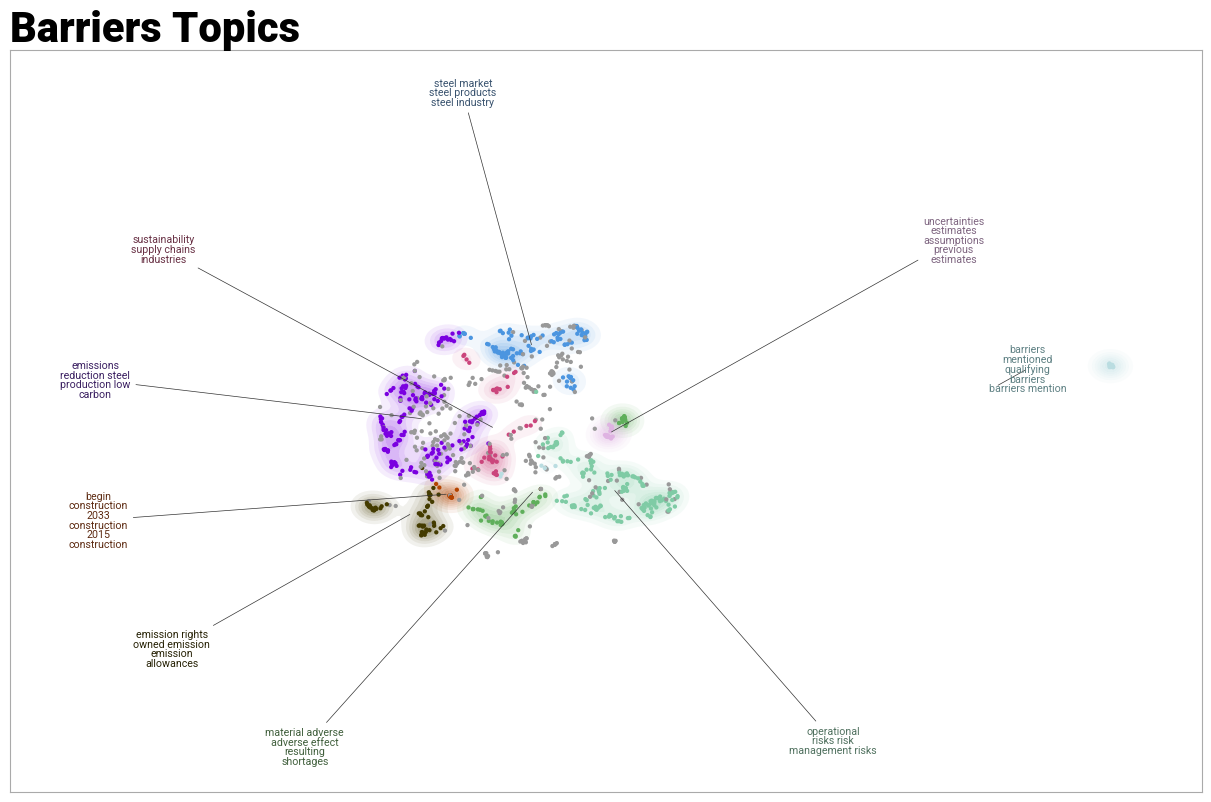

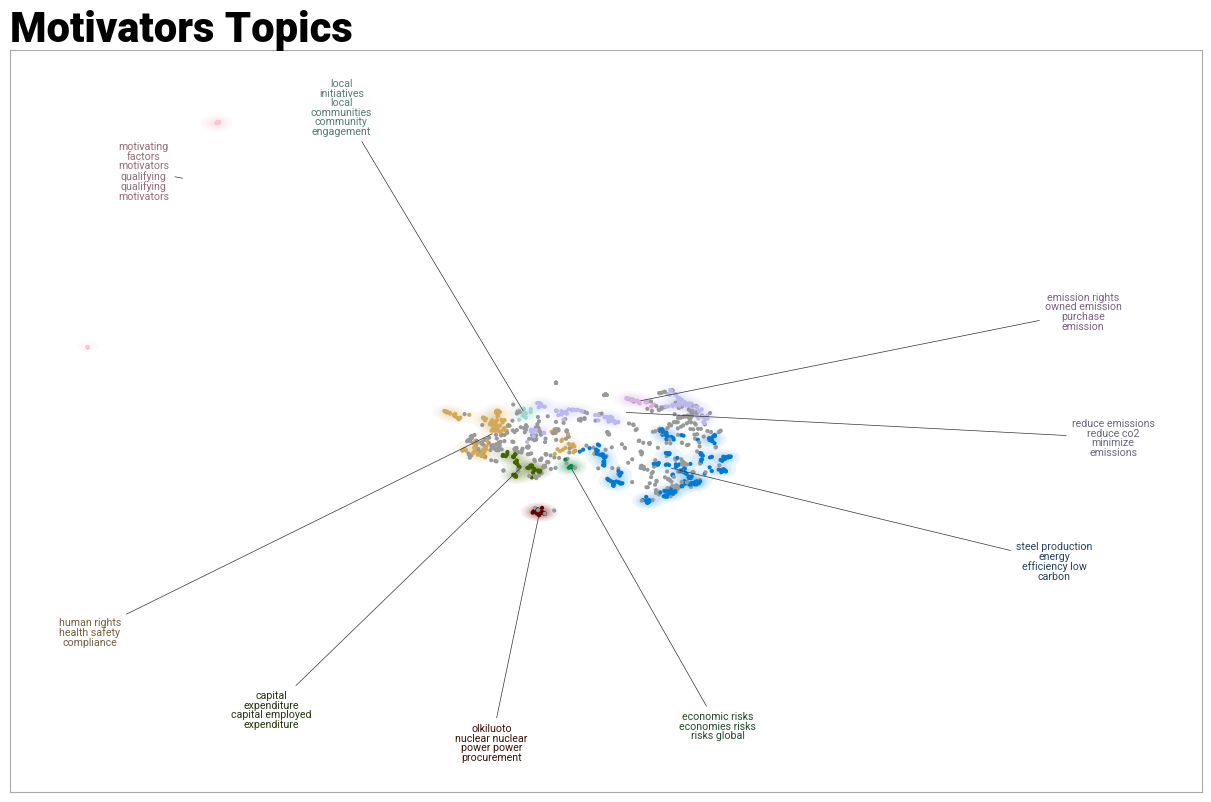

In [1]:
# from bertopic.representation import OpenAI,LlamaCPP
from nlp import TopicModelConfig, run_topic_modeling_pipeline

# Set True to ignore cached model/embeddings and retrain from scratch
FORCE_RETRAIN = True

config = TopicModelConfig(
    # Embedding model
    embedding_model="sentence-transformers/all-mpnet-base-v2",
    batch_size=64,

    # UMAP (dimensionality reduction)
    umap_n_neighbors=30,
    umap_n_components=15,
    umap_min_dist=0.05,
    umap_metric='cosine',
    umap_random_state=42,

    # HDBSCAN (clustering)
    hdbscan_min_cluster_size=10,  # Higher = fewer topics
    hdbscan_min_samples=2,        # Lower = less outliers
    hdbscan_metric='euclidean',
    hdbscan_cluster_selection_method='leaf',  # 'eom' (inclusive) or 'leaf' (tight, more cleanup required)

    # Vectorizer (c-TF-IDF)
    vectorizer_ngram_range=(1, 2),
    vectorizer_min_df=1,
    vectorizer_max_df=0.95,

    # Topic representation
    mmr_diversity=0.2, # 0 - pure relevance, redundant/simi word ... 1 - pure diverse. max diff word
    top_n_words=10,
    nr_topics=10,  # Set None for auto, or int to reduce post-hoc
    calculate_probabilities=True,

    # Outlier reduction (post-hoc)
    reduce_outliers=False,  # Reassign outliers to nearest topic
    reduce_outliers_strategy='embeddings',  # 'embeddings', 'c-tf-idf', or 'distributions'

    # Visualization UMAP (separate 2D projection)
    viz_umap_n_neighbors=10,
    viz_umap_n_components=2,
    viz_umap_min_dist=0.0,

    # LLM for topic labeling
    ollama_model="llama3.1:8b",
    ollama_base_url="http://localhost:11434",
    llm_temperature=0.0,

    # Misc
    verbose=True,
    embeddings_cache_path=None,
)

results = run_topic_modeling_pipeline(
    data_folder="../out",
    output_folder="../out/topics5",
    config=config,
    force_retrain=FORCE_RETRAIN
)
# Access results
barriers_df = results['barriers']['df']
motivators_df = results['motivators']['df']

In [ ]:
motivators_df